# 🧹 Exploratory Data Analysis & Data Preprocessing

## Overview

This notebook performs exploratory data analysis (EDA) and prepares the Kaggle mental health text dataset for deep learning models.

Tasks include:

- Loading the dataset
- Exploring class distribution
- Checking missing values
- Cleaning text data
- Removing stopwords
- Encoding labels
- Tokenizing text
- Preparing padded sequences for the BiLSTM model

The processed outputs are used by the model training notebooks.


# 🧠 Mental Health Risk Detection Using Deep Learning

## 📌 Project Introduction
This project applies deep learning models to classify free-text statements into mental health sentiment categories such as **Anxiety**, **Depression**, **Suicidal**, and others.  
We trained and evaluated both a **Bidirectional LSTM** and a fine-tuned **DistilBERT** model.

## 📊 Dataset Overview
- **Source:** [Kaggle – Sentiment Analysis for Mental Health](https://www.kaggle.com/datasets/suchintikasarkar/sentiment-analysis-for-mental-health)
- **Classes:** Normal, Anxiety, Depression, Suicidal, Stress, Bipolar, Personality Disorder
- **Total Samples:** ~61,000 labeled entries

## 🧼 Preprocessing Summary (for BiLSTM)
- Text cleaned: lowercased, punctuation removed, links & special characters stripped
- Label encoding applied using `LabelEncoder`
- Tokenized with Keras `Tokenizer` (vocab size = 10,000)
- Sequences padded to `maxlen = 100`
- Train/validation/test split using stratification
- Class weights computed to address label imbalance

## 🧠 Model 1: Bidirectional LSTM
- Tokenized input passed to an Embedding layer
- 2 stacked Bidirectional LSTM layers with dropout
- Batch normalization layer for stability
- Dense layer with 16 units and final output layer (7-class softmax)
- Trained using class weights and validation monitoring

## 🤖 Model 2: DistilBERT
- Used HuggingFace `DistilBertForSequenceClassification`
- Tokenized with `DistilBertTokenizerFast`
- Fine-tuned on the same labeled dataset
- Output head configured for 7 sentiment classes

## 📈 Evaluation Summary
- Accuracy, precision, recall, and F1-score reported for each model
- Confusion matrix visualized for class-level analysis
- Training history (accuracy/loss over epochs) plotted

## 🌐 Streamlit App
- Web interface created with Streamlit
- Users enter a sentence or paragraph
- Backend runs either **BiLSTM** or **DistilBERT** for classification
- Confidence scores and class breakdowns shown
- UI toggle to switch between Technical and Layman views

### 🔧 Running the App

The Streamlit app is launched independently from the notebook using:

```bash
streamlit run app.py

The app allows:

- Selection between BiLSTM and DistilBERT
- Text input box for user statements
- Results shown with confidence scores
- Optional toggle for simplified (layman) output

Note: Streamlit cannot be run inside a Jupyter Notebook.

Below is a screenshot of the app 
![Streamlit App UI](images/Streamlit_UI_DeepLearning1.jpg)

## 🧪

## 👥

## ✅

# EDA & Preprocessing
### By Manpreet Singh, Lev Byzalov & Cheungkwan Li

In [11]:
# preprocessing work done mostly by Manpreet Singh

# imports
from google.colab import drive
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import math
import pickle

In [12]:
# --- Configuration ---
CSV_FILE_PATH = 'raw_data.csv'
TEXT_COLUMN_NAME = 'statement'
LABEL_COLUMN_NAME = 'status'
MAX_VOCAB_SIZE = 10000 # Max number of unique words to keep in vocabulary
MAX_SEQUENCE_LENGTH = 100 # Pad sequences to this length
EMBEDDING_DIM = 100 # Dimension of word embeddings

In [15]:
# Mount Google Drive
drive.mount('/content/drive')

# Path to your shared project folder
project_path = "/content/drive/MyDrive/MathForDeepLearning_Project"

# Check if the path exists
if not os.path.exists(project_path):
    raise FileNotFoundError(
        "⚠️ Project folder 'DeepLearning1_Project' not found in your Google Drive. "
        "Please make sure you've added it to your Drive using 'Add shortcut to Drive'."
    )

# Example file paths inside your project
data_path = os.path.join(project_path, "data/raw", CSV_FILE_PATH)
print("Drive mounted successfully. Data path set to:", data_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted successfully. Data path set to: /content/drive/MyDrive/MathForDeepLearning_Project/data/raw/raw_data.csv


In [16]:
training_set = pd.read_csv(data_path)
training_set.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [17]:
# load dataset
training_set = pd.read_csv(data_path)
training_set.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [18]:
training_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


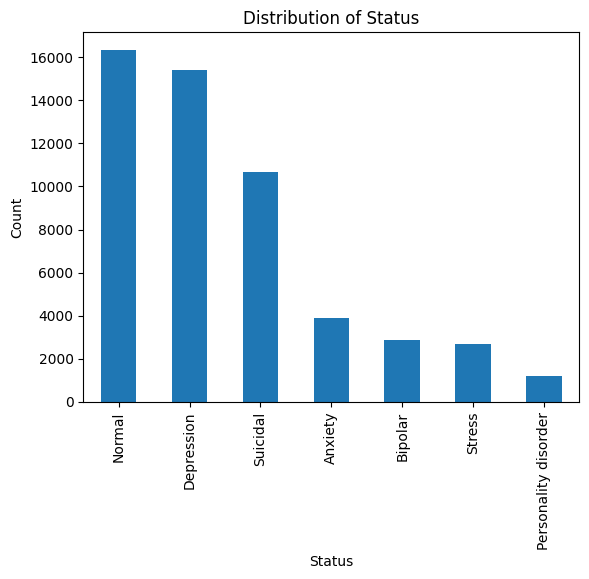

In [19]:
#plot distribution
training_set['status'].value_counts().plot(kind='bar')
plt.xlabel('Status')
plt.ylabel('Count')
plt.title('Distribution of Status')
plt.show()

In [20]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [21]:
training_set.dropna(inplace=True)
#remove stopwords
stop_words = set(stopwords.words('english'))
training_set['statement'] = training_set['statement'].astype(str).fillna('')
training_set['statement'] = training_set['statement'].apply(lambda x: ' '.join([word for word in x.split() if word.lower() not in stop_words]))

training_set.info()


<class 'pandas.core.frame.DataFrame'>
Index: 52681 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  52681 non-null  int64 
 1   statement   52681 non-null  object
 2   status      52681 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.6+ MB


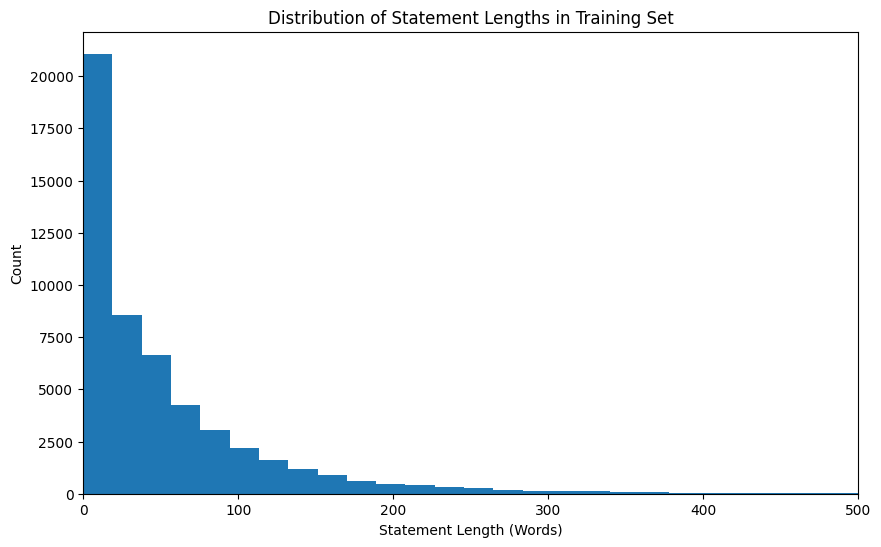

In [22]:
training_set['statement_length'] = training_set['statement'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
training_set['statement_length'].plot(kind='hist', bins=200)
plt.xlim(0, 500)
plt.xlabel('Statement Length (Words)')
plt.ylabel('Count')
plt.title('Distribution of Statement Lengths in Training Set')
plt.show()

In [23]:
# --- Data Preprocessing ---

# 1. Select relevant columns
if TEXT_COLUMN_NAME not in training_set.columns:
    print(f"Error: Text column '{TEXT_COLUMN_NAME}' not found in the CSV.")
    print(f"Available columns: {training_set.columns.tolist()}")
    exit()
if LABEL_COLUMN_NAME not in training_set.columns:
    print(f"Error: Label column '{LABEL_COLUMN_NAME}' not found in the CSV.")
    print(f"Available columns: {training_set.columns.tolist()}")
    exit()

texts = training_set[TEXT_COLUMN_NAME].astype(str).tolist() # Ensure text is string type
labels = training_set[LABEL_COLUMN_NAME].tolist()

In [24]:
# 2. Encode Labels (if they are not already numerical 0/1)
# For binary classification (mental issue / no mental issue)
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)
print(f"\nOriginal Labels: {labels[:5]}...")
print(f"Encoded Labels (first 5): {encoded_labels[:5]}...")
print(f"Label classes: {label_encoder.classes_}")


Original Labels: ['Anxiety', 'Anxiety', 'Anxiety', 'Anxiety', 'Anxiety']...
Encoded Labels (first 5): [0 0 0 0 0]...
Label classes: ['Anxiety' 'Bipolar' 'Depression' 'Normal' 'Personality disorder' 'Stress'
 'Suicidal']


In [25]:
# 3. Tokenization and Padding
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<unk>")
tokenizer.fit_on_texts(texts)
word_index = tokenizer.word_index
print(f"\nFound {len(word_index)} unique tokens.")

sequences = tokenizer.texts_to_sequences(texts)
padded_sequences = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

print(f"First 5 original texts: {texts[:5]}")
print(f"First 5 padded sequences: {padded_sequences[:5]}")


Found 63289 unique tokens.
First 5 original texts: ['oh gosh', 'trouble sleeping, confused mind, restless heart. tune', 'wrong, back dear, forward doubt. Stay restless restless place', 'shifted focus something else still worried', 'restless restless, month now, boy. mean?']
First 5 padded sequences: [[ 525 4824    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0]
 [ 864  558  888  167 1180  202 8699    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0 

In [26]:
# 4. Save padded sequences and encoded labels as processed data
proc_data = pd.DataFrame(padded_sequences)
proc_data['encoded_labels'] = pd.Series(encoded_labels)

In [27]:
proc_data.head()

,0,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,encoded_labels
0,525,4824,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,864,558,888,167,1180,202,8699,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,180,30,2151,505,1047,256,1180,1180,193,0,...,0,0,0,0,0,0,0,0,0,0
3,7289,623,36,89,33,331,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1180,1180,194,76,1298,297,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [28]:
#download proc_data
from google.colab import files
proc_data.to_csv('processed_data2.csv', index=False)
files.download('processed_data2.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
# save processed data to drive

out_path = os.path.join(project_path, "data/processed", "processed_data.csv")
proc_data.to_csv(out_path)

In [30]:
# --- Save Tokenizer ---
TOKENIZER_SAVE_PATH = 'tokenizer.pickle'

with open(TOKENIZER_SAVE_PATH, 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Tokenizer saved to: {TOKENIZER_SAVE_PATH}")

Tokenizer saved to: tokenizer.pickle
